# Creating the Graph to make the new correlation matrix

In [1]:
from tara_preprocessing import full_preprocessing,make_rbf_correlation_matrix,get_just_ecog_data,get_electrode_normalized_loc,make_patient_correlation_matrix
from pathlib import Path
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
import networkx as nx

data_root = Path("/Users/noahwanless/Desktop/Spring2026/M467/faces_basic/data")
registered_dir = Path("../SuperEeg-M467-project/registered_outputs")
ecogs = get_just_ecog_data(registered_dir,data_root)
xyz = get_electrode_normalized_loc(registered_dir)

xyz_clean, mapping_clean, kept_global_indices, cleaned = full_preprocessing(ecogs,xyz)

patient_corr_mat = make_patient_correlation_matrix(xyz_clean,cleaned,mapping_clean)

[PosixPath('../SuperEeg-M467-project/registered_outputs/aa_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ap_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ca_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/de_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/fp_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ha_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/ja_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jm_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/jt_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/mv_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_outputs/rn_xslocs_registered_mm.npy'), PosixPath('../SuperEeg-M467-project/registered_output

# Graph of the nodes on the brain

In [2]:
from sklearn.neighbors import NearestNeighbors
from tqdm import tqdm
k = 10
num_nodes = 649
neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node

# turn indices lists into pairwiase combos
all_edges = []
iter = 0
for indexs in indicesofneigh:
    #temp = []
    for num in indexs:
        all_edges.append((iter,num))
    iter += 1
    
G = nx.Graph()
nodes = np.arange(num_nodes)
G.add_nodes_from(nodes)
G.add_edges_from(all_edges)

Glaplacian = nx.linalg.laplacian_matrix(G).toarray() #gets the laplacian of the bain graph for use to use

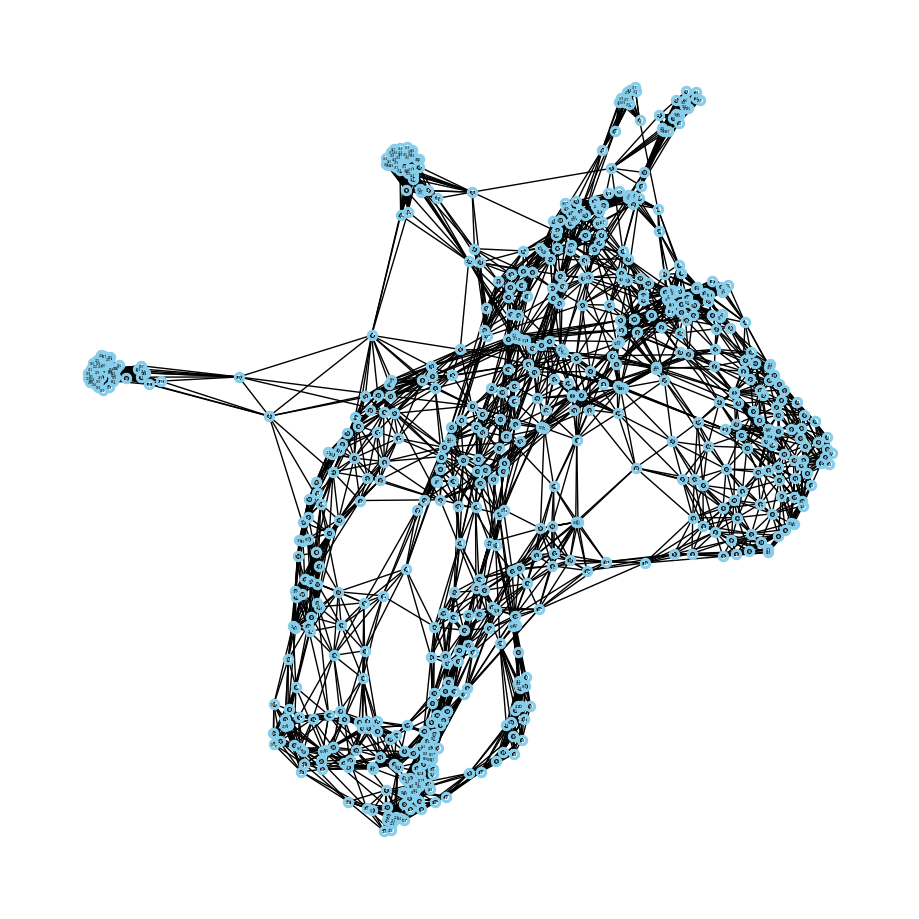

In [3]:
plt.figure(figsize=(9, 9))
pos = nx.spring_layout(G) # Position nodes using Fruchterman-Reingold force-directed algorithm
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=5, edge_color='k', linewidths=6, font_size=2)
plt.show()

# PyTorch implementaion of our objective function

See notes, but U will have a shape (649,r) which we will iterate through by taking chunks of size (n,r) where n is the number of observed electrodes for that patient, this means this value changes for each paitent but will sum to 649 or whatever the total number of nodes is.

generally increasing r will increase the approximation and complexity of U, however it comes at the cost of computation time and complexity and potentially a risk of overtraining (although i dont know if overtraining is a issue here)

In [4]:
import torch

patient_node_num = []# this is how many nodes each paitent has
r = 100 #This is the rank of the approximation, or the number of columns of U
L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=True)
U = torch.rand((649,r),requires_grad=True)
C = [] #this is your list of correlation matrixs
lamb = 1
for corr in patient_corr_mat:
    C.append(torch.tensor(np.array(corr),requires_grad=True))
    patient_node_num.append(corr.shape[0])


def object_func(C,U,L,lamb):
    sum = torch.tensor(0,dtype=torch.float32,requires_grad=True)
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 +lamb*torch.trace(U.T@L@U)
        iter += num_nodes
    return sum


### Training and evaluation

In [5]:
optimizer = torch.optim.Adam([U], lr=0.01) 
loss_list = []
for step in tqdm(range(1000)):
    optimizer.zero_grad()
    z = object_func(C,U,L,lamb) #this is our loss function
    loss_list.append(z.detach())
    z.backward()
    optimizer.step()

100%|██████████| 1000/1000 [00:12<00:00, 80.30it/s]


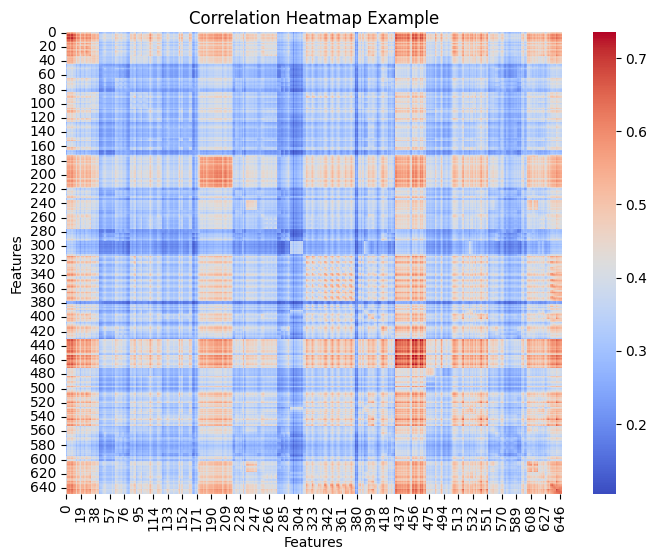

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(U.detach()@U.detach().T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

### Graph of the loss function

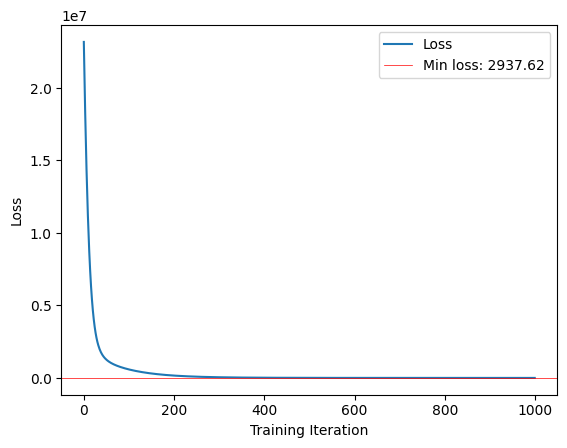

In [7]:
min = np.min(loss_list)
plt.plot(loss_list,label='Loss')
plt.axhline(y=min,c='red',label=f"Min loss: {round(min,2)}",linewidth=.5)
plt.xlabel('Training Iteration')
plt.ylabel('Loss')
plt.legend()

set tanh inverse before the correltaion matrixs are used or turned into requires_grad setting also make graph of the loss function, and add the lambda as a thing
mabye, dont know whether the correlation needs the normalization factor, the z function, the definitnion is in the paper

the objective function is convex so there is no local min
and try predicting something or not and etc

## Creating U matrix function:

This wraps together several steps in making the U matrix to make it easier to use.\
NOTE: The object function needs to be defined and based into this function for things to work

In [8]:
# object_func: this is the object function Javier gave us to minimize
# C list of patient corelation matrices
# L lapacian of the graph of electrodes connected to its k nearest ones
# lamb, the scaling factor on the trace portion of the model 
def object_func(C,U,L,lamb):
    sum = torch.tensor(0,dtype=torch.float32,requires_grad=True)
    iter = 0
    for i in range(14):
        c = C[i] #each patient correlation matrix
        num_nodes = patient_node_num[i]
        u = U[iter:iter+num_nodes,:] #all columns of rows iter+num of nodes + 1 
        sum = sum + (torch.linalg.norm((u@u.T - c),ord='fro'))**2 +lamb*torch.trace(U.T@L@U)
        iter += num_nodes
    return sum

##############################
# create_u_matrix: creates the U matrix
# r: the 'complexity' of our approximation (the number of columns of our U matrix we will make)
# k: the number of nearest neighbors a electrode is 'connected to'
# lamb: the parameter on trace aspect of the loss function
# xyz_clean: normalized electrode locations on the brain
# patient_corr_mat: the list of indivdual patient correlation matrices (ONLY containing the nodes they obsevered on them)
# object_func: the objective function we want to minimize
# training_steps: number of steps to train the function (usually 500 should be enough, defaults to 1000)
# use_z: whether or not to use the Z function on the patient correlation matrices before we use them (defaults to no)
######### retruns #########
# U: this is the big U matrix, to get our correlation matrix do U@U.T 
# Loss: this is the list of loss at each step of training to ensure that the function is converging
##############################
def create_u_matrix(r,k,lamb,xyz_clean,patient_corr_mat,object_func,training_steps=1000,use_z=False):
    ######## get num_nodes ########
    num_nodes = 0 #(usually will be 649 unless some other code changes)
    for corr in patient_corr_mat:
        num_nodes += corr.shape[1]
    ############## Create graph ##############
    neigh = NearestNeighbors(n_neighbors=k).fit(xyz_clean)
    indicesofneigh = neigh.kneighbors()[1] #gets the indices of the 10 (or k) neighbors of each node
    all_edges = []
    iter = 0
    for indexs in indicesofneigh:# turn indices lists into pairwiase combos
        for num in indexs:
            all_edges.append((iter,num))
        iter += 1
        
    G = nx.Graph()
    nodes = np.arange(num_nodes)
    G.add_nodes_from(nodes)
    G.add_edges_from(all_edges)

    Glaplacian = nx.linalg.laplacian_matrix(G).toarray() #gets the laplacian of the bain graph for use to use
    ############## Build arguements for objective function ##############
    patient_node_num = []# this is how many nodes each paitent has
    r = 200 #This is the rank of the approximation, or the number of columns of U
    L = torch.tensor(Glaplacian,dtype=torch.float32,requires_grad=True)
    U = torch.rand((649,r),requires_grad=True)
    C = [] #this is your list of correlation matrixs
    lamb = 1
    for corr in patient_corr_mat:
        if use_z: #if we want to, we pass the correlation matrix through a normalization function z() (defined as the inverse of the tanh function)
            raise NotImplementedError("Dont use this yet, we run into an error were we divide by zero some how")
            #TODO:
            #TODO: This happens because at x=-1,1, arctanh is -inf or inf, so we have to account
            #TODO: for this somehow, because its a correlation matrix im not sure how we would do that.
            #TODO: Ask Javier during class
            #TODO:
            C.append(torch.tensor(np.arctanh(np.array(corr)),requires_grad=True))    
        else:
            C.append(torch.tensor(np.array(corr),requires_grad=True))
        patient_node_num.append(corr.shape[0])

    ############## train U ##############
    optimizer = torch.optim.Adam([U], lr=0.01) 
    loss_list = []
    print("Training")
    for step in tqdm(range(training_steps)):
        optimizer.zero_grad()
        z = object_func(C,U,L,lamb) #this is our loss function
        loss_list.append(z.detach())
        z.backward()
        optimizer.step()

    return U.detach(),loss_list

Training


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:17<00:00, 56.78it/s]


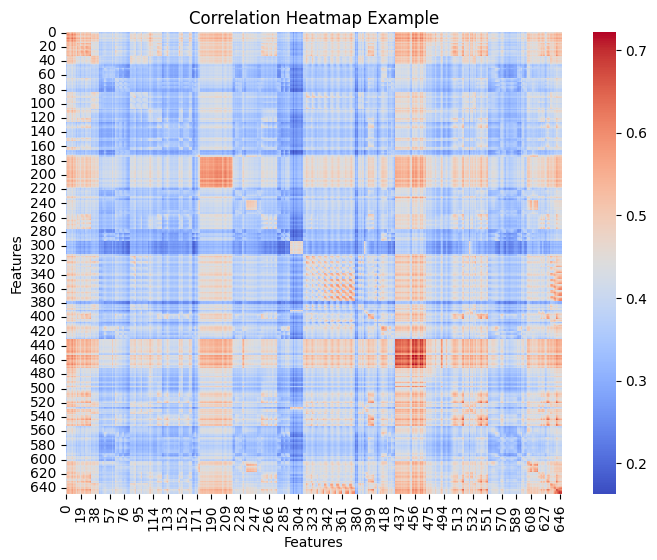

In [9]:
U,loss = create_u_matrix(r=200,k=15,lamb=1,xyz_clean=xyz_clean,patient_corr_mat=patient_corr_mat,object_func=object_func,use_z=False)
plt.figure(figsize=(8, 6))
sns.heatmap(U@U.T, cmap='coolwarm') 
plt.title('Correlation Heatmap Example')
plt.xlabel('Features')
plt.ylabel('Features')
plt.show()

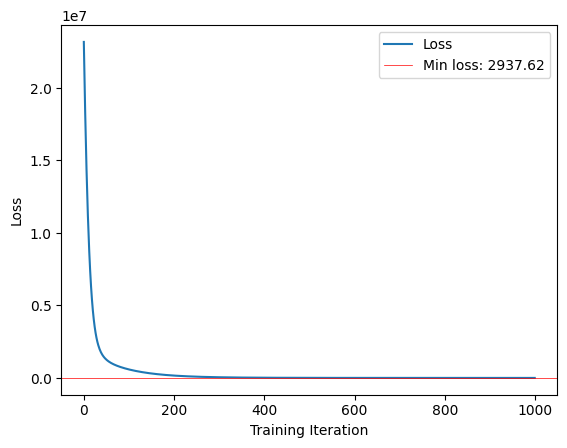

In [10]:
min = np.min(loss_list)
plt.plot(loss_list,label='Loss')
plt.axhline(y=min,c='red',label=f"Min loss: {round(min,2)}",linewidth=.5)
plt.xlabel('Training Iteration')
plt.ylabel('Loss')
plt.legend()

# My quess of something being wrong is that one of the dimensions is fliped, and while the size is right, its orientated wrong

In [22]:
def single_patient_prediction_clean(patient,electrodestart,electrodeend,ecogs,correlation_matrix):
    #this gets everything for this patient, the correlation of the observed and unobserved datapoints
    ####### Normalizes patient data #######
    Y = ecogs[patient] #gets this paitents data
    row_means = np.mean(Y, axis=0, keepdims=True) #normalization through a whole electrodes timeline
    row_stds = np.std(Y, axis=0, keepdims=True)
    Y_z_score = (Y - row_means) / row_stds #turns them into there z_score for each value in the data
    ####### Prepare K matrices #######
    K_patient = correlation_matrix[:,electrodestart:electrodeend+1] #this gets all the electrodes that the patient has with their own correlation and that of others
    print('K_patient.shape')
    print(K_patient.shape)
    Kalpha_alpha = K_patient[electrodestart:electrodeend+1,:] #gets all the rows that the patient has observed data for
    print('Kalpha_alpha.shape')
    print(Kalpha_alpha.shape)
    Kbeta_alpha = K_patient[electrodeend+1:,:] #* get all rows the patient doesnt have observed 
    print('Kbeta_alpha.shape')
    print(Kbeta_alpha.shape)
    Y_patient = Y_z_score[:,electrodestart:electrodeend+1] #gets all the z_score values from electrodes the patient we did observed
    Y_true = Y_z_score[:,electrodeend+1:] #gets all the z_score values from electrodes the patient we didnt observed (for potential comparison later)
    Yt = Y_patient.T #take the transpose of it
    print('Yt.shape')
    print(Yt.shape)
    Kalpha_alpha_inv = np.linalg.inv(Kalpha_alpha) 
    print('Kalpha_alpha_inv.shape')
    print(Kalpha_alpha_inv.shape)
    pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T #using formula from paper
    
    return pred, Y_true


In [23]:
pred,y_true = single_patient_prediction_clean(0,0,10,ecogs,U@U.T)
pred_np = pred.numpy()

K_patient.shape
torch.Size([649, 11])
Kalpha_alpha.shape
torch.Size([11, 11])
Kbeta_alpha.shape
torch.Size([638, 11])
Yt.shape
(11, 271400)
Kalpha_alpha_inv.shape
torch.Size([11, 11])


/var/folders/8t/y5v94x215r973w80szwrht8r0000gq/T/ipykernel_9849/2190076906.py:26: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  pred = ((Kbeta_alpha@Kalpha_alpha_inv)@Yt).T #using formula from paper


# NOTE FOR CLASS TO ASK
It seems that as we go along the nodes the scale of the predication gets bigger and bigger to the point of insanity

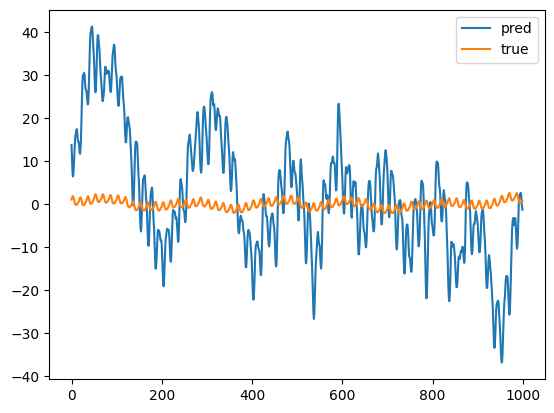

In [47]:
plt.plot(pred_np[1000:2000,20],label='pred')
plt.plot(y_true[1000:2000,20],label='true')
plt.legend()

# Additionally of note is this behiavor which doesnt make sense:

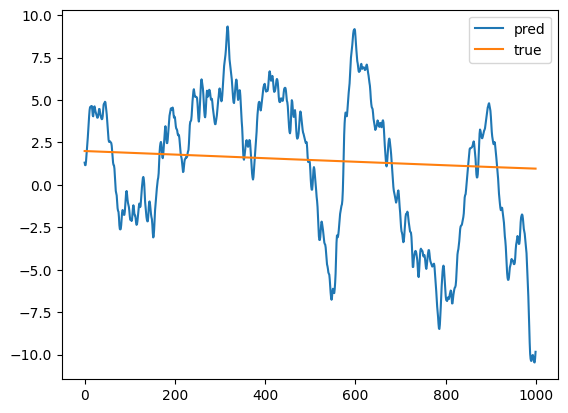

In [46]:
plt.plot(pred_np[1000:2000,30],label='pred')
plt.plot(y_true[1000:2000,30],label='true')
plt.legend()

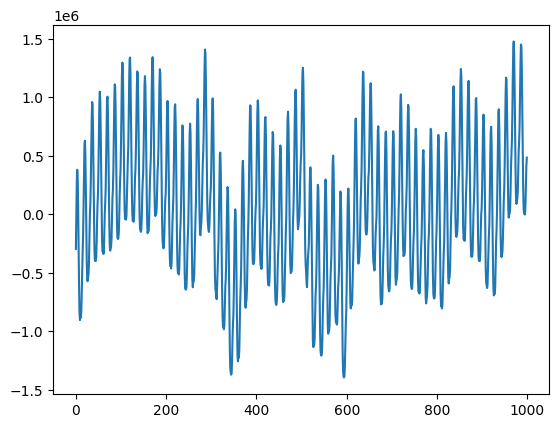